1. Generating Logical Synthetic Data (Moving Hand Simulation)...
Data ready! X_train shape: (320, 10, 32, 32, 1)

2. Building the CNN-LSTM Architecture...

3. Training the Model...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8938 - loss: 0.8366 - val_accuracy: 1.0000 - val_loss: 0.3687
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9969 - loss: 0.1078 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 9.6214e-04
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 7.3502e-04
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/ste

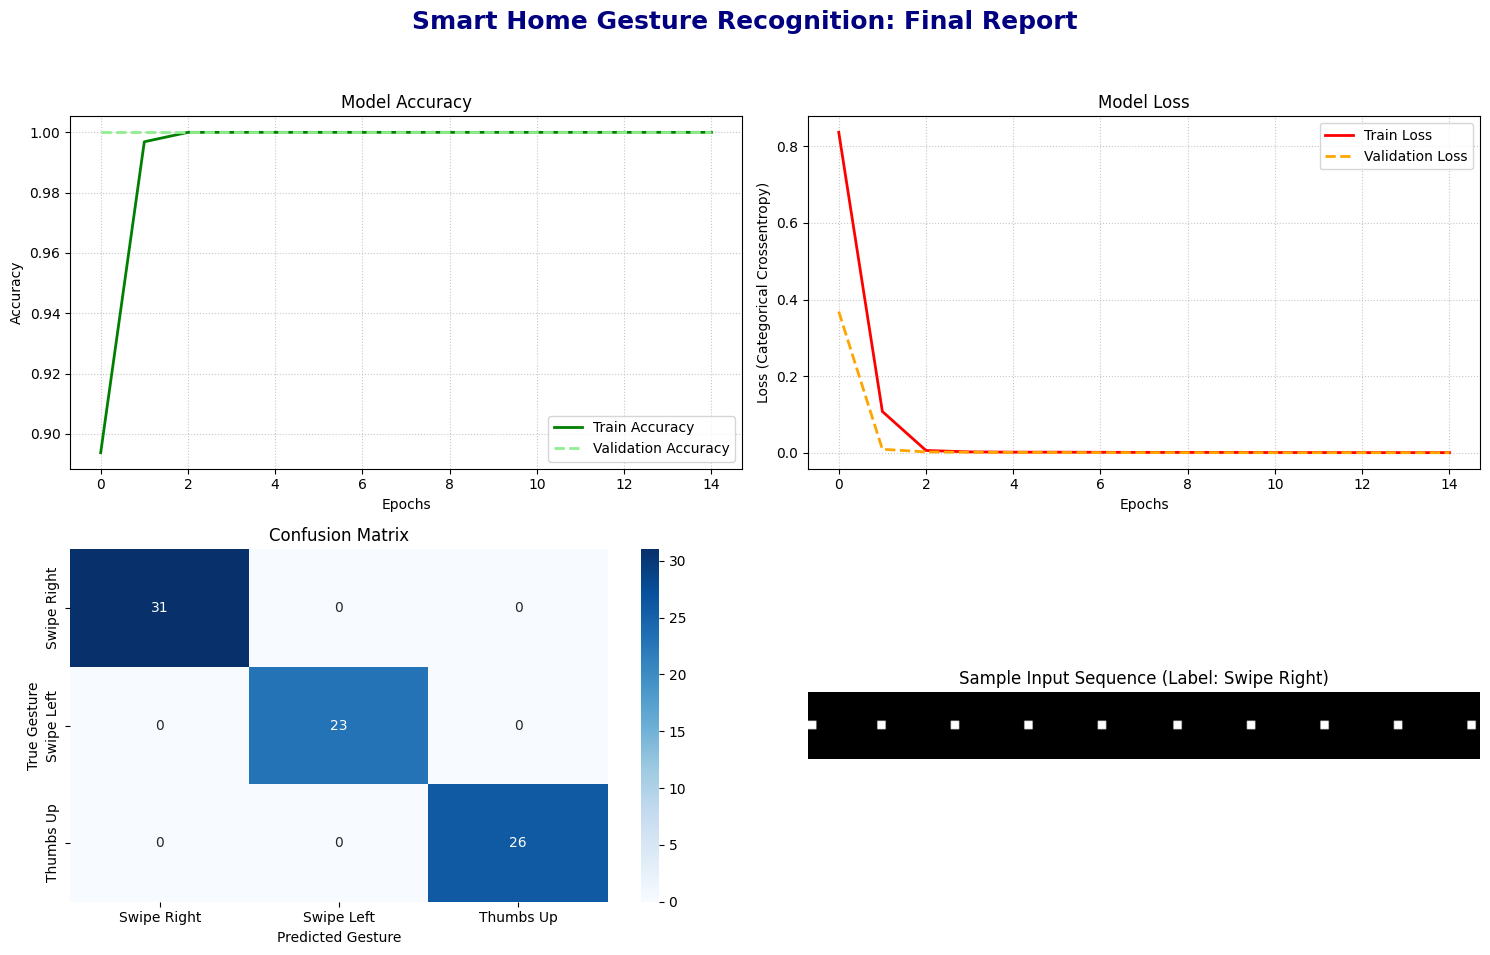


✅ Final Test Accuracy: 100.00%


In [3]:
# ==============================================================================
# مشروع: Gesture Recognition for Smart Home Control باستخدام CNN-LSTM
# ==============================================================================

# 1. استدعاء المكتبات الأساسية
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("1. Generating Logical Synthetic Data (Moving Hand Simulation)...")
# ==============================================================================
# 2. توليد بيانات منطقية تحاكي حركة اليد (3 إيماءات)
# ==============================================================================
num_samples = 400       # عدد الفيديوهات (البيانات)
frames_per_video = 10   # عدد الإطارات في الفيديو الواحد
height, width = 32, 32  # حجم الإطار
channels = 1            # قناة لونية واحدة (Grayscale)
num_classes = 3         # 0: Swipe Right, 1: Swipe Left, 2: Thumbs Up (Hold)

X = np.zeros((num_samples, frames_per_video, height, width, channels), dtype=np.float32)
y = np.zeros((num_samples,), dtype=np.int32)

for i in range(num_samples):
    gesture = np.random.randint(0, num_classes)
    y[i] = gesture
    row = height // 2

    for t in range(frames_per_video):
        col = width // 2
        if gesture == 0:   # Swipe Right (تشغيل النور)
            col = int((t / frames_per_video) * width)
        elif gesture == 1: # Swipe Left (إطفاء النور)
            col = int((1 - t / frames_per_video) * width)

        col = min(width - 3, max(2, col))
        X[i, t, row-2:row+2, col-2:col+2, 0] = 1.0 # رسم المربع (الإيد)

# One-Hot Encoding
y_cat = tf.keras.utils.to_categorical(y, num_classes)

# تقسيم البيانات (80% تدريب - 20% اختبار)
split_idx = int(0.8 * num_samples)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y_cat[:split_idx], y_cat[split_idx:]

print(f"Data ready! X_train shape: {X_train.shape}")

print("\n2. Building the CNN-LSTM Architecture...")
# ==============================================================================
# 3. بناء معمارية CNN-LSTM
# ==============================================================================
model = Sequential([
    Input(shape=(frames_per_video, height, width, channels)),

    # استخراج الميزات المكانية (Spatial Features)
    TimeDistributed(Conv2D(8, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2))),

    TimeDistributed(Conv2D(16, (3, 3), activation='relu', padding='same')),
    TimeDistributed(MaxPooling2D((2, 2))),

    TimeDistributed(Flatten()),

    # معالجة التتابع الزمني (Temporal Dependencies)
    LSTM(32, activation='tanh'),
    Dropout(0.2),

    # الطبقات المتصلة بالكامل لاستخراج القرار
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n3. Training the Model...")
# ==============================================================================
# 4. تدريب النموذج
# ==============================================================================
history = model.fit(X_train, y_train, epochs=15, batch_size=16, validation_data=(X_test, y_test), verbose=1)

print("\n4. Generating Final Report & Visualizations...")
# ==============================================================================
# 5. التقييم والرسومات البيانية (الداشبورد)
# ==============================================================================

# أ. حفظ صورة المعمارية
plot_model(model, to_file='cnn_lstm_architecture.png', show_shapes=True, show_layer_names=True, dpi=90)
print("-> Model architecture saved as 'cnn_lstm_architecture.png'")

# ب. رسم منحنيات الأداء (Accuracy & Loss)
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Smart Home Gesture Recognition: Final Report', fontsize=18, fontweight='bold', color='navy')

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='lightgreen', linewidth=2, linestyle='--')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(history.history['loss'], label='Train Loss', color='red', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss (Categorical Crossentropy)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

# ج. رسم مصفوفة الارتباك (Confusion Matrix)
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true_classes, y_pred_classes)

ax3 = fig.add_subplot(2, 2, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=["Swipe Right", "Swipe Left", "Thumbs Up"],
            yticklabels=["Swipe Right", "Swipe Left", "Thumbs Up"])
ax3.set_title('Confusion Matrix')
ax3.set_ylabel('True Gesture')
ax3.set_xlabel('Predicted Gesture')

# د. عرض عينة من الفريمات لتوضيح الفكرة للدكتور/المعيد
ax4 = fig.add_subplot(2, 2, 4)
sample_idx = 0 # أول عينة في بيانات الاختبار
sample_frames = X_test[sample_idx]
sample_label = y_true_classes[sample_idx]
gesture_names = {0: "Swipe Right", 1: "Swipe Left", 2: "Thumbs Up"}

# دمج الفريمات في صورة واحدة جنب بعض
combined_frames = np.hstack([sample_frames[t, :, :, 0] for t in range(frames_per_video)])
ax4.imshow(combined_frames, cmap='gray')
ax4.set_title(f'Sample Input Sequence (Label: {gesture_names[sample_label]})')
ax4.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# طباعة النتيجة النهائية
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final Test Accuracy: {acc * 100:.2f}%")